Let's download some samples from Zenodo. https://zenodo.org/record/5546663#.YrvAoy1h2Zw

In [6]:
!wget https://zenodo.org/record/5546663/files/IGWN-GWTC3p0-v1-GW191109_010717_PEDataRelease_mixed_nocosmo.h5

--2022-06-28 23:05:16--  https://zenodo.org/record/5546663/files/IGWN-GWTC3p0-v1-GW191109_010717_PEDataRelease_mixed_nocosmo.h5
Resolving zenodo.org (zenodo.org)... 137.138.76.77
Connecting to zenodo.org (zenodo.org)|137.138.76.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 374495928 (357M) [application/octet-stream]
Saving to: ‘IGWN-GWTC3p0-v1-GW191109_010717_PEDataRelease_mixed_nocosmo.h5’

IGWN-GWTC3p0-v1-GW1 100%[===================>] 357.15M  18.7MB/s    in 20s     

2022-06-28 23:05:38 (18.1 MB/s) - ‘IGWN-GWTC3p0-v1-GW191109_010717_PEDataRelease_mixed_nocosmo.h5’ saved [374495928/374495928]



We could read this file with PESummary, but we can also just read it directly with `h5py`.

In [7]:
import h5py

In [8]:
path = "IGWN-GWTC3p0-v1-GW191109_010717_PEDataRelease_mixed_nocosmo.h5"
f = h5py.File(path, 'r')

Let's look at the contents of the file. There should be several versions of parameter estimation with different waveforms (and `Mixed` which mixes them together---we won't use that).

In [9]:
f.keys()

<KeysViewHDF5 ['C01:IMRPhenomXPHM', 'C01:Mixed', 'C01:SEOBNRv4PHM', 'history', 'version']>

Let's look at the IMRPhenomXPHM posterior.

In [10]:
f["C01:IMRPhenomXPHM"].keys()

<KeysViewHDF5 ['approximant', 'calibration_envelope', 'config_file', 'description', 'injection_data', 'meta_data', 'posterior_samples', 'priors', 'psds', 'skymap', 'version']>

There's a lot of useful data there. Let's grab the posteiror samples.

In [12]:
samples = f["C01:IMRPhenomXPHM"]["posterior_samples"][()]

The object `samples` is now a `numpy` array of sample values. Look at the first one:

In [14]:
samples[0]

(49.83796952, 0.47550625, 0.76094274, 0.97779026, 2.68089553, 2.33125286, 1.43867327, 5.4794171, 1.86400836, 2.88303856, 0.95087449, 3.16668241, 1.23991265, -0.0345347, -0.03027852, 0.02633217, 0.00612017, 0.02118842, 0.00483064, -0.02262716, 0.01399977, -0.00912521, 0.0077975, 0.00762875, 0.00898645, 0.01673635, 0.00153966, -0.00325621, 0.00043218, -0.00900994, 0.02093193, -0.00096529, 0.00584457, 0.03638164, -0.0142964, 0.06758084, 0.02025775, -0.00939106, 0.00021786, -0.02526524, 0.00014082, -0.00751683, 0.02485568, 0.0213544, 0.00276958, -0.10831524, 0.00395862, -0.03166127, -0.00679669, 0.00657231, -0.00048339, 0.01633011, 0.00641051, -0.00043257, 841.1004016, 1.25729686e+09, 20., 28.25254356, 39.91031089, 56.37838986, 79.64164577, 112.50395334, 158.92614214, 224.50338771, 317.13958708, 448., 20., 28.25254356, 39.91031089, 56.37838986, 79.64164577, 112.50395334, 158.92614214, 224.50338771, 317.13958708, 448., 139.33682696, 91.65241743, 124.16404871, 84.15013375, 40.01391496, 4.063

We can see the meaning of the samples by getting their names:

In [15]:
samples.dtype.names

('chirp_mass',
 'mass_ratio',
 'a_1',
 'a_2',
 'tilt_1',
 'tilt_2',
 'phi_12',
 'phi_jl',
 'theta_jn',
 'psi',
 'phase',
 'azimuth',
 'zenith',
 'recalib_H1_amplitude_0',
 'recalib_H1_amplitude_1',
 'recalib_H1_amplitude_2',
 'recalib_H1_amplitude_3',
 'recalib_H1_amplitude_4',
 'recalib_H1_amplitude_5',
 'recalib_H1_amplitude_6',
 'recalib_H1_amplitude_7',
 'recalib_H1_amplitude_8',
 'recalib_H1_amplitude_9',
 'recalib_H1_phase_0',
 'recalib_H1_phase_1',
 'recalib_H1_phase_2',
 'recalib_H1_phase_3',
 'recalib_H1_phase_4',
 'recalib_H1_phase_5',
 'recalib_H1_phase_6',
 'recalib_H1_phase_7',
 'recalib_H1_phase_8',
 'recalib_H1_phase_9',
 'recalib_L1_amplitude_0',
 'recalib_L1_amplitude_1',
 'recalib_L1_amplitude_2',
 'recalib_L1_amplitude_3',
 'recalib_L1_amplitude_4',
 'recalib_L1_amplitude_5',
 'recalib_L1_amplitude_6',
 'recalib_L1_amplitude_7',
 'recalib_L1_amplitude_8',
 'recalib_L1_amplitude_9',
 'recalib_L1_phase_0',
 'recalib_L1_phase_1',
 'recalib_L1_phase_2',
 'recalib_L1_phas

So you can histogram the mass of the heaviest black hole (`mass_1`) by doing:

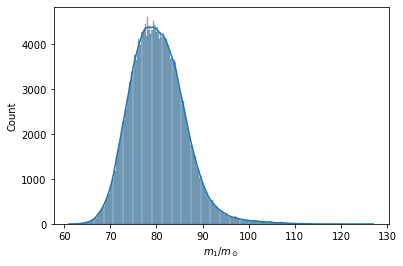

In [20]:
import seaborn as sns
g = sns.histplot(samples['mass_1'], kde=True)
g.axes.set_xlabel(r'$m_1/m_\odot$');

You should remember to close the file when you are done.

In [21]:
f.close()

Actually, the best practice to do the data with a `with` statement.

In [24]:
with h5py.File(path, 'r') as f:
    samples = f["C01:IMRPhenomXPHM"]["posterior_samples"][()]

And now there's no need to explicitly close the file.